## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math 
import scipy.stats as stats
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [5]:
df = pd.read_csv('dataset/Country-data.csv')
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Dataset Overview

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
df.shape

(167, 10)

In [9]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [10]:
df.describe(include=object)

,country
count,167
unique,167
top,Afghanistan
freq,1


## 4. Missing & Duplicate Values Analysis

In [12]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


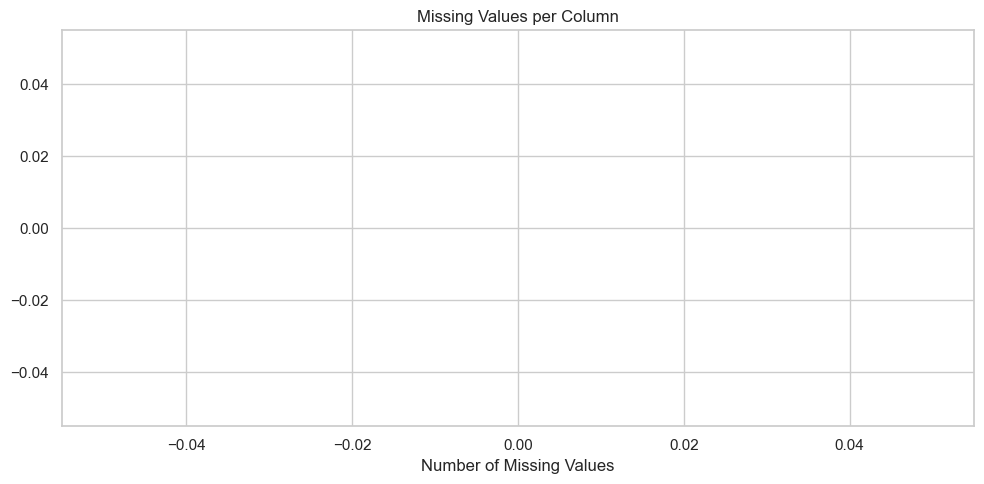

In [13]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+0.5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


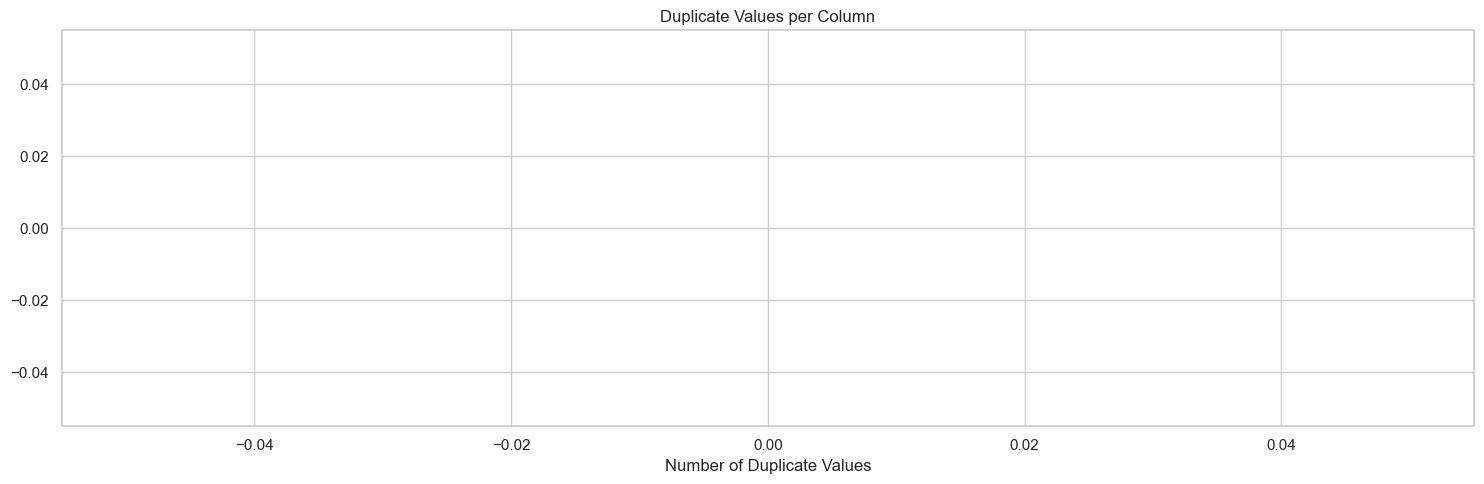

In [15]:
fig,ax = plt.subplots(figsize=(15,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.005,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Univariat Analysis -- Numerical Features

In [17]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:10])

Numeric features (9):
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


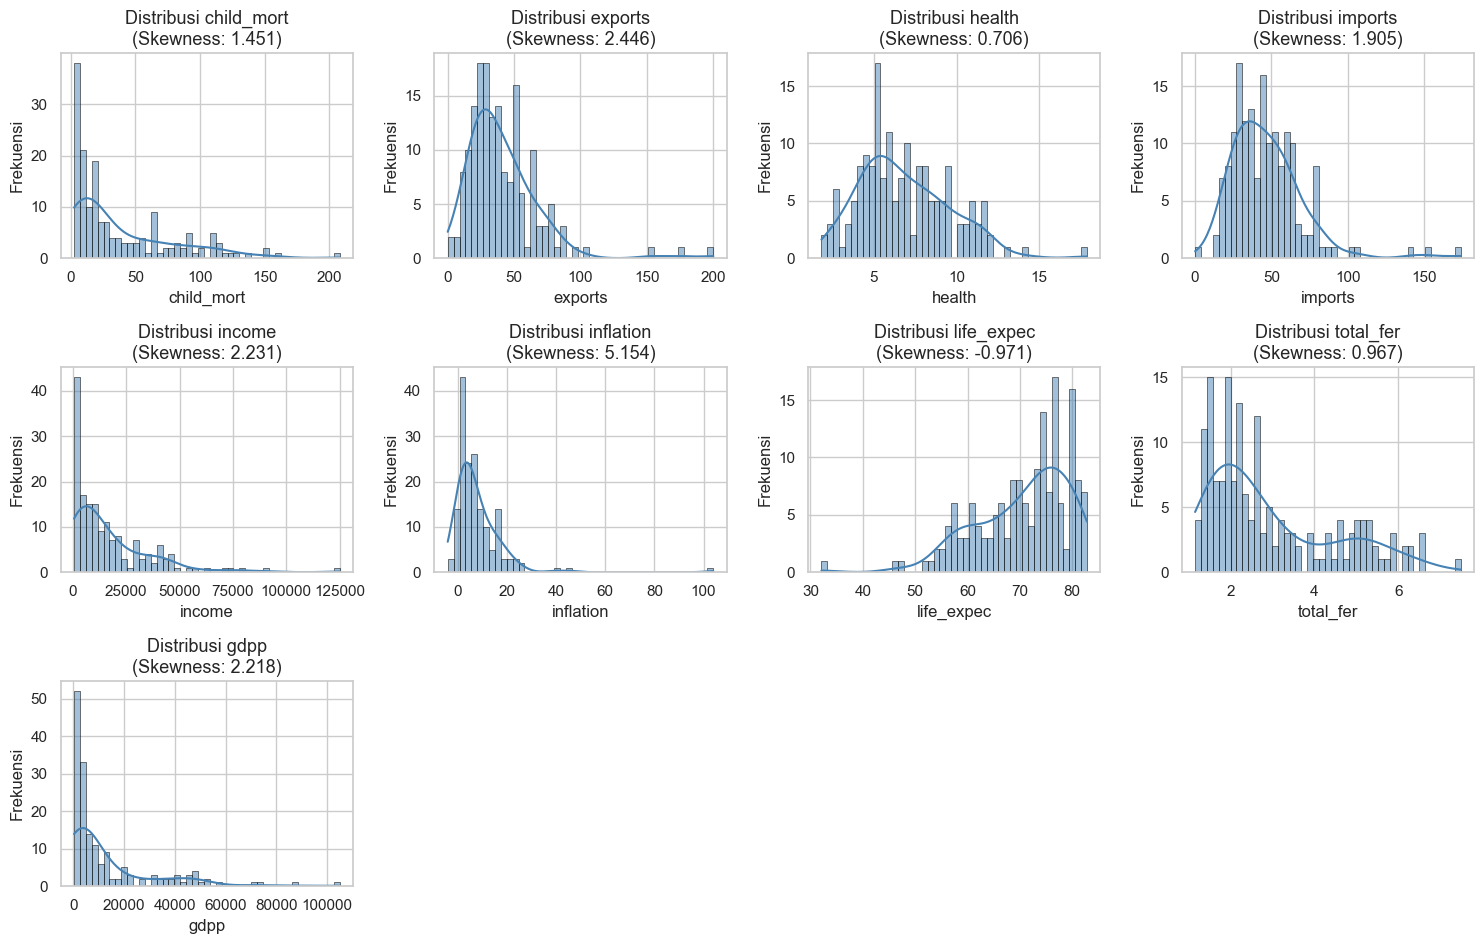

In [18]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 6. Multivariat Analysis

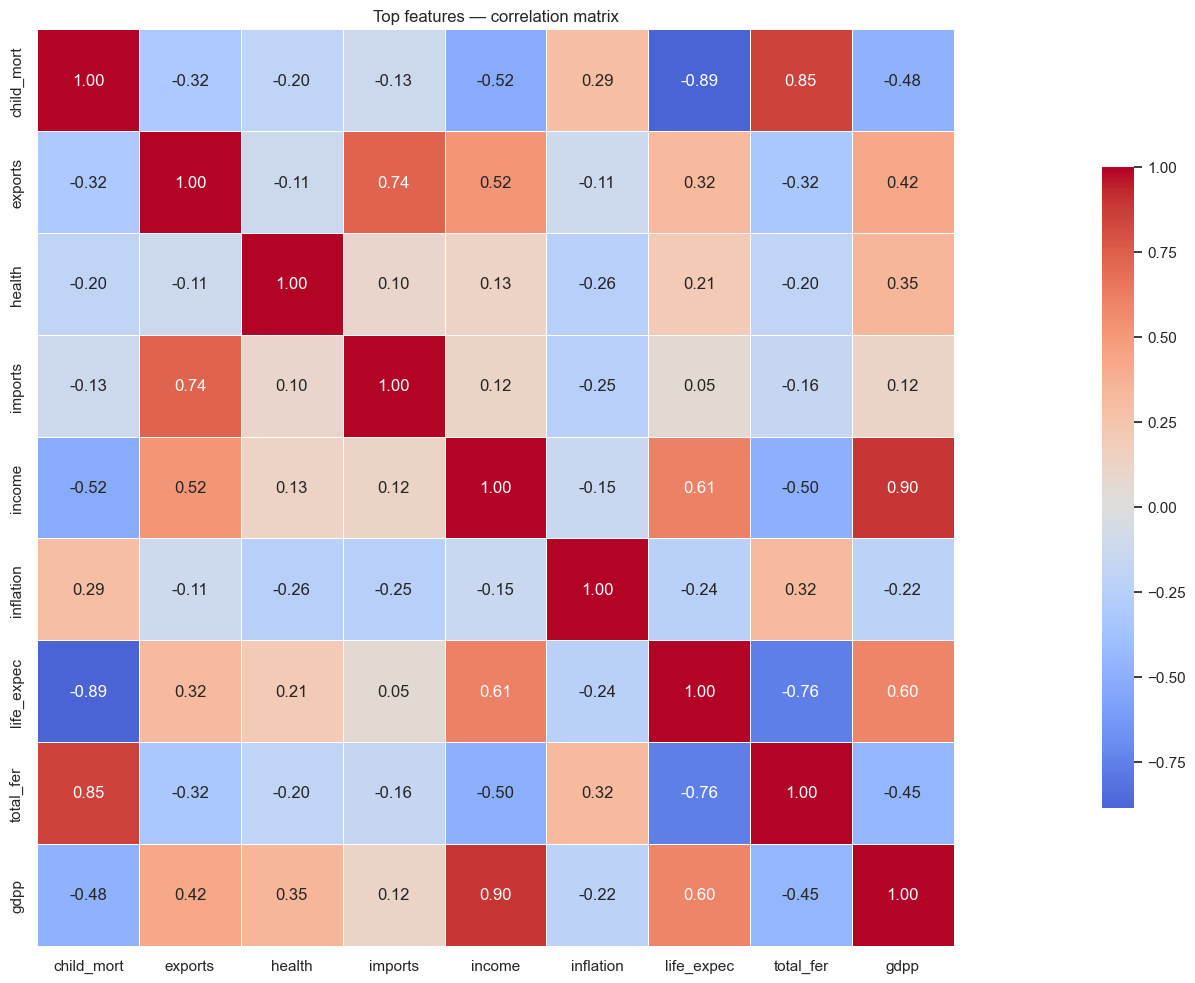

In [35]:
corr_matrix = df[feature_numerik].corr()
plt.figure(figsize=(30,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

## 8. Summary of Key Findings

In [37]:
summary = pd.DataFrame({
    'Metric': [
        'Total Samples', 
        'Total Features', 
        'Numeric Features', 
        'Categorical Features', 
        'Missing Values', 
        'Duplicate Rows', 
        'Memory Usage (MB)'
    ],
    'Value': [
        len(df),
        df.shape[1],
        len(df.select_dtypes(include='number').columns),
        len(df.select_dtypes(include=['object', 'category']).columns),
        df.isna().sum().sum(),
        df.duplicated().sum(),
        round(df.memory_usage(deep=True).sum() / (1024 * 1024), 2)
    ],
})
summary

,Metric,Value
0,Total Samples,167.00
1,Total Features,10.00
2,Numeric Features,9.00
3,Categorical Features,1.00
4,Missing Values,0.00
5,Duplicate Rows,0.00
6,Memory Usage (MB),0.02
